<a href="https://colab.research.google.com/github/kishor-cypto/projects/blob/main/Skin_Cancer_Classification_Using_CNN_on_ISIC_9_Class_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)


import os
import json
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.image as mpimg


from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [5]:
base_dir = '/content/drive/MyDrive/Skin cancer ISIC The International Skin Imaging Collaboration'

train_dir = os.path.join(base_dir, 'Train')
test_dir = os.path.join(base_dir, 'Test')

print("Classes:", os.listdir(train_dir))

Classes: ['basal cell carcinoma', 'squamous cell carcinoma', 'pigmented benign keratosis', 'seborrheic keratosis', 'vascular lesion', 'nevus', 'melanoma', 'actinic keratosis', 'dermatofibroma']


In [7]:
img_size = 128

batch_size = 32


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)


test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [8]:
train_generator = train_datagen.flow_from_directory(

    train_dir,

    target_size=(img_size,img_size),

    batch_size=batch_size,

    class_mode='categorical'
)



test_generator = test_datagen.flow_from_directory(

    test_dir,

    target_size=(img_size,img_size),

    batch_size=batch_size,

    class_mode='categorical',

    shuffle=False
)

Found 2239 images belonging to 9 classes.
Found 118 images belonging to 9 classes.


In [9]:
model = models.Sequential([


    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(img_size,img_size,3)
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(2,2),



    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(2,2),



    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(2,2),



    layers.GlobalAveragePooling2D(),


    layers.Dense(
        128,
        activation='relu'
    ),


    layers.Dropout(0.5),



    layers.Dense(
        train_generator.num_classes,
        activation='softmax'
    )

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

In [11]:
history = model.fit(

    train_generator,

    epochs=10,

    validation_data=test_generator

)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 624s 9s/step - accuracy: 0.2702 - loss: 2.0893 - val_accuracy: 0.1356 - val_loss: 2.2263
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.3819 - loss: 1.7394 - val_accuracy: 0.1356 - val_loss: 2.2662
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.4274 - loss: 1.6528 - val_accuracy: 0.1356 - val_loss: 2.2836
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.4377 - loss: 1.6007 - val_accuracy: 0.1356 - val_loss: 2.2920
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.4587 - loss: 1.5570 - val_accuracy: 0.1441 - val_loss: 2.2627
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.4547 - loss: 1.5402 - val_accuracy: 0.2288 - val_loss: 2.1476
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.4690 - loss: 1.4929 - val_accuracy: 0.3051 - val_loss: 2.0198
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.4685 - loss: 1.4803 - val_accuracy: 0.3220 - v

In [12]:
test_loss,test_accuracy = model.evaluate(
    test_generator
)


print(
    "Test Loss =",
    test_loss
)


print(
    "Test Accuracy =",
    test_accuracy*100,"%"
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3475 - loss: 1.9649
Test Loss = 1.9649407863616943
Test Accuracy = 34.7457617521286 %


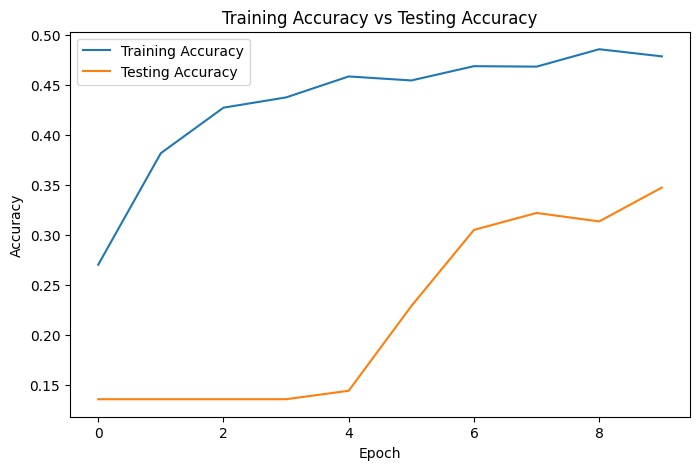

In [13]:
plt.figure(figsize=(8,5))


plt.plot(
    history.history['accuracy']
)


plt.plot(
    history.history['val_accuracy']
)



plt.title(
    "Training Accuracy vs Testing Accuracy"
)


plt.xlabel("Epoch")

plt.ylabel("Accuracy")


plt.legend(
    [
        "Training Accuracy",
        "Testing Accuracy"
    ]
)


plt.show()

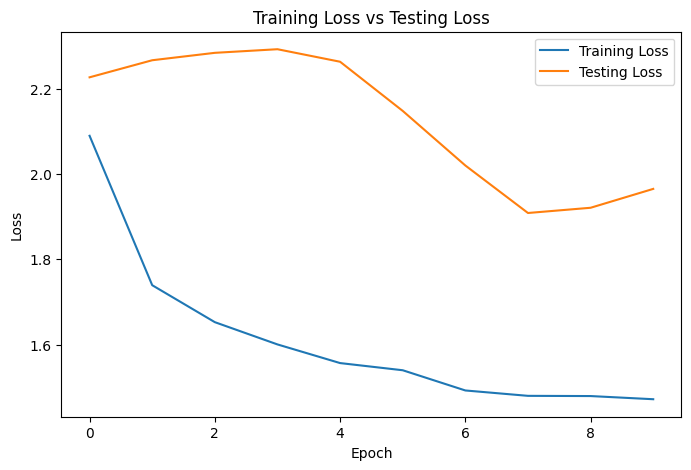

In [14]:
plt.figure(figsize=(8,5))


plt.plot(
    history.history['loss']
)


plt.plot(
    history.history['val_loss']
)



plt.title(
    "Training Loss vs Testing Loss"
)


plt.xlabel("Epoch")

plt.ylabel("Loss")


plt.legend(
    [
        "Training Loss",
        "Testing Loss"
    ]
)


plt.show()

In [15]:
test_generator.reset()


predictions = model.predict(
    test_generator
)


y_pred = np.argmax(
    predictions,
    axis=1
)


y_true = test_generator.classes

4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step


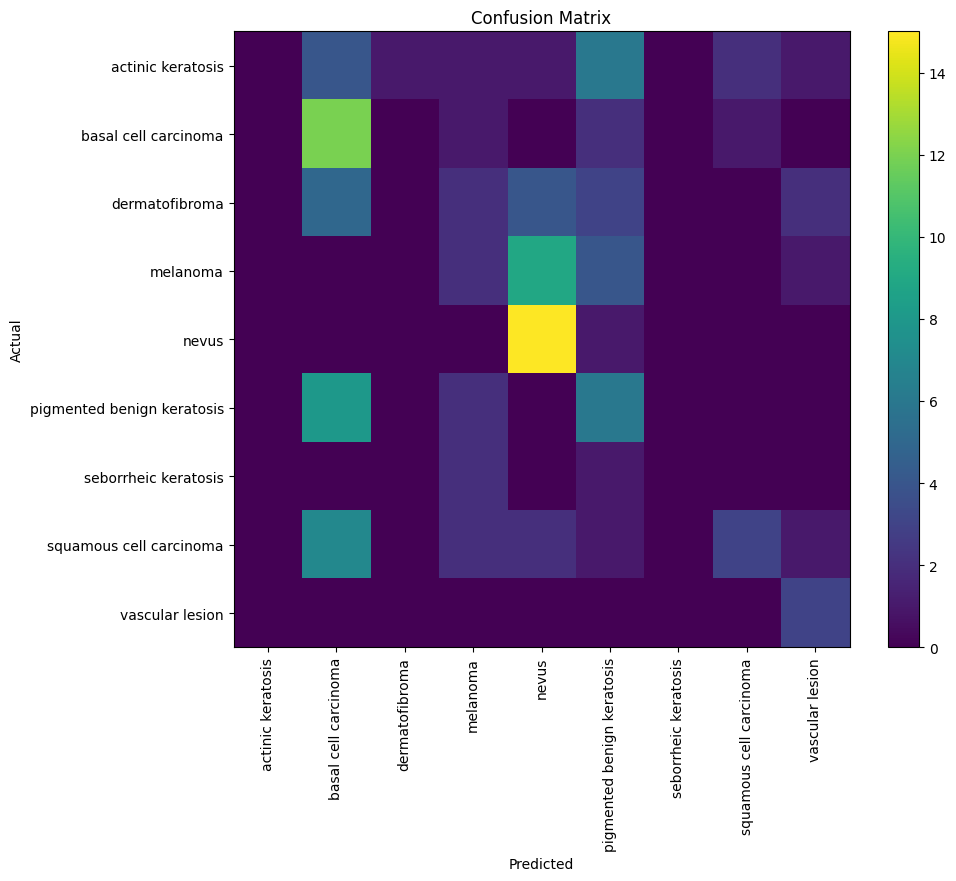

In [16]:
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(
    y_true,
    y_pred
)


plt.figure(figsize=(10,8))


plt.imshow(cm)


plt.title("Confusion Matrix")


plt.colorbar()



classes = list(
    test_generator.class_indices.keys()
)


plt.xticks(
    np.arange(len(classes)),
    classes,
    rotation=90
)


plt.yticks(
    np.arange(len(classes)),
    classes
)


plt.xlabel("Predicted")

plt.ylabel("Actual")


plt.show()

In [17]:
from sklearn.metrics import classification_report


print(
classification_report(
    y_true,
    y_pred,
    target_names=classes
)
)

                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        16
      basal cell carcinoma       0.33      0.75      0.46        16
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.17      0.12      0.14        16
                     nevus       0.48      0.94      0.64        16
pigmented benign keratosis       0.25      0.38      0.30        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.50      0.19      0.27        16
           vascular lesion       0.38      1.00      0.55         3

                  accuracy                           0.35       118
                 macro avg       0.23      0.38      0.26       118
              weighted avg       0.24      0.35      0.26       118



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
from sklearn.metrics import f1_score


f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)


print(
    "F1 Score =",
    f1
)

F1 Score = 0.260026234133699


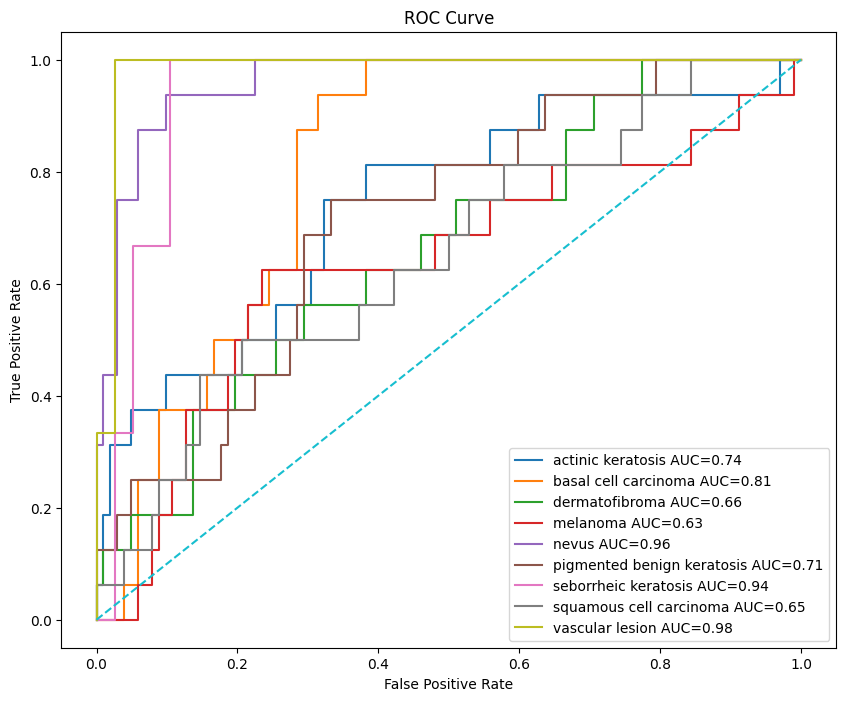

In [19]:
from sklearn.preprocessing import label_binarize

from sklearn.metrics import roc_curve, auc



y_true_binary = label_binarize(
    y_true,
    classes=np.arange(
        len(classes)
    )
)



plt.figure(figsize=(10,8))


for i in range(len(classes)):


    fpr,tpr,_ = roc_curve(

        y_true_binary[:,i],

        predictions[:,i]

    )


    roc_auc = auc(
        fpr,
        tpr
    )


    plt.plot(
        fpr,
        tpr,
        label=classes[i]+" AUC="+str(round(roc_auc,2))
    )



plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "ROC Curve"
)


plt.legend()


plt.show()

In [20]:
from sklearn.metrics import roc_auc_score


roc_auc = roc_auc_score(

    y_true_binary,

    predictions,

    multi_class='ovr'

)


print(
    "ROC AUC Score =",
    roc_auc
)

ROC AUC Score = 0.7880772236430805


In [21]:
def load_and_preprocess_image(
    image_path,
    target_size=(128,128)
):

    img = Image.open(image_path)


    img = img.resize(
        target_size
    )


    img_array=np.array(img)


    img_array=np.expand_dims(
        img_array,
        axis=0
    )


    img_array=img_array.astype(
        'float32'
    )/255.


    return img_array

In [22]:
class_indices = {
    v:k for k,v in train_generator.class_indices.items()
}


json.dump(
    class_indices,
    open("class_indices.json","w")
)

In [26]:
image_path='/content/drive/MyDrive/Skin cancer ISIC The International Skin Imaging Collaboration/Test/melanoma/ISIC_0000004.jpg'


img = load_and_preprocess_image(
    image_path
)


prediction = model.predict(
    img
)


index = np.argmax(
    prediction
)


print(
    "Predicted Class:",
    class_indices[index]
)


print(
    "Confidence:",
    np.max(prediction)*100,
    "%"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted Class: melanoma
Confidence: 35.729248 %
